In [2]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("C:\ML_Projects\Supply_Chain_Risk_Analytics\data\data.csv")

df.head()

,timestamp,device_id,location,temperature,humidity,vibration_level,inventory_status,stock_quantity,order_id,order_placed_date,...,actual_delivery_date,supplier_id,supplier_rating,logistics_partner,shipment_status,social_media_feed,news_alert,weather_condition,system_log_message,manual_risk_label
0,2024-03-27 11:21:41,sensor_2,Hub_C,27.48,48.62,1.98,in-stock,188,ORD5506,2024-03-19 11:21:41,...,2024-03-29 11:21:41,SUP_117,2.78,DHL,delivered,Supply chain normal,Stable market,sunny,System normal,0
1,2025-02-27 14:22:08,sensor_6,Hub_C,24.53,40.71,0.61,in-stock,359,ORD7912,2025-02-22 14:22:08,...,2025-03-02 14:22:08,SUP_111,1.08,FedEx,in-transit,Supply chain normal,Stable market,sunny,System normal,0
2,2025-01-27 12:30:19,sensor_39,Warehouse_A,22.10,44.75,0.30,in-stock,459,ORD4257,2025-01-12 12:30:19,...,2025-01-29 12:30:19,SUP_153,1.03,FedEx,delayed,Supply chain normal,Stable market,sunny,System normal,0
3,2025-04-02 16:42:30,sensor_18,Warehouse_A,25.11,45.72,0.77,in-stock,475,ORD3615,2025-03-22 16:42:30,...,2025-04-22 16:42:30,SUP_135,1.93,FedEx,in-transit,Possible delay reported,Minor strikes reported,rainy,Warning threshold exceeded,1
4,2024-09-18 10:34:37,sensor_7,Warehouse_A,26.11,42.32,0.72,in-stock,243,ORD7224,2024-09-12 10:34:37,...,2024-09-20 10:34:37,SUP_144,1.19,UPS,in-transit,Supply chain normal,Stable market,sunny,System normal,0


In [5]:
df.shape

(3000, 21)

In [6]:
df.columns

Index(['timestamp', 'device_id', 'location', 'temperature', 'humidity',
       'vibration_level', 'inventory_status', 'stock_quantity', 'order_id',
       'order_placed_date', 'expected_delivery_date', 'actual_delivery_date',
       'supplier_id', 'supplier_rating', 'logistics_partner',
       'shipment_status', 'social_media_feed', 'news_alert',
       'weather_condition', 'system_log_message', 'manual_risk_label'],
      dtype='object')

In [7]:
df.describe()

,temperature,humidity,vibration_level,stock_quantity,supplier_rating,manual_risk_label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,24.895820,49.945477,1.481863,249.599667,2.992870,0.334333
std,5.188619,10.198968,1.501984,144.333108,1.151905,0.493257
min,7.600000,16.120000,0.000000,0.000000,1.000000,0.000000
25%,21.407500,43.137500,0.400000,124.000000,1.990000,0.000000
50%,24.950000,50.090000,1.020000,250.000000,2.990000,0.000000
75%,28.440000,56.780000,2.052500,374.000000,3.980000,1.000000
max,42.090000,80.870000,13.200000,499.000000,5.000000,2.000000


In [8]:
df.isnull().sum()

timestamp                 0
device_id                 0
location                  0
temperature               0
humidity                  0
vibration_level           0
inventory_status          0
stock_quantity            0
order_id                  0
order_placed_date         0
expected_delivery_date    0
actual_delivery_date      0
supplier_id               0
supplier_rating           0
logistics_partner         0
shipment_status           0
social_media_feed         0
news_alert                0
weather_condition         0
system_log_message        0
manual_risk_label         0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.drop_duplicates()

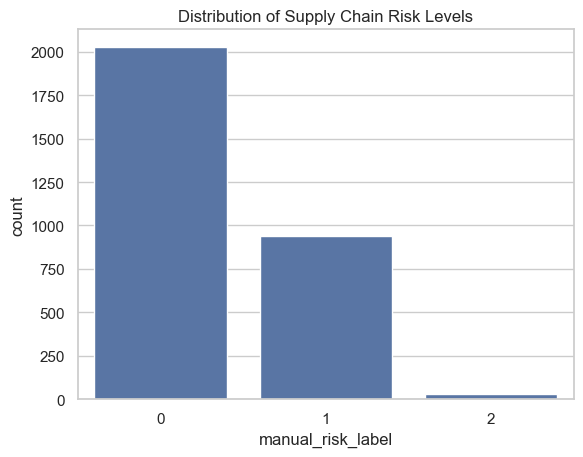

In [11]:
sns.countplot(data=df, x="manual_risk_label")
plt.title("Distribution of Supply Chain Risk Levels")
plt.show()

# Most operations fall under the No Risk category.
# Moderate and High Risk events occur less frequently.
# This indicates a class imbalance in the dataset.

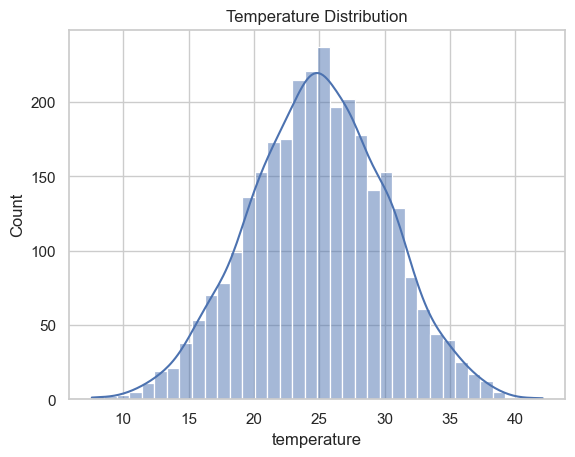

In [28]:
sns.histplot(df["temperature"], kde=True)

plt.title("Temperature Distribution")

plt.show()

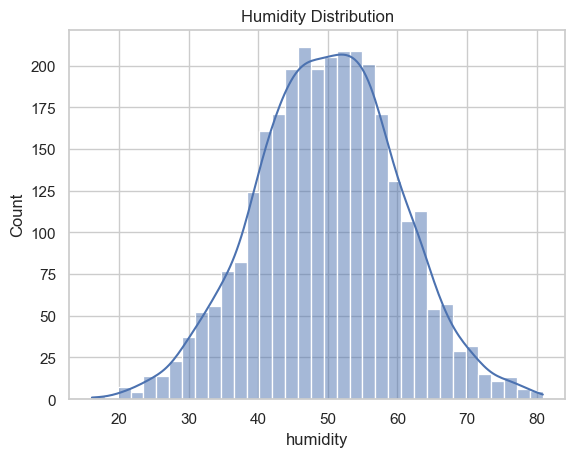

In [29]:
sns.histplot(df["humidity"], kde=True)

plt.title("Humidity Distribution")

plt.show()

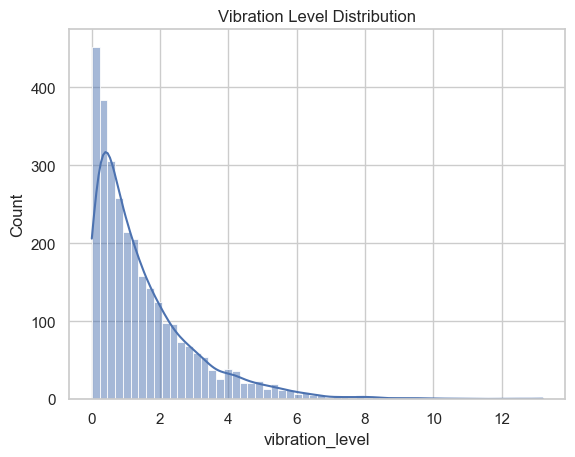

In [30]:
sns.histplot(df["vibration_level"], kde=True)

plt.title("Vibration Level Distribution")

plt.show()

<Axes: xlabel='temperature'>

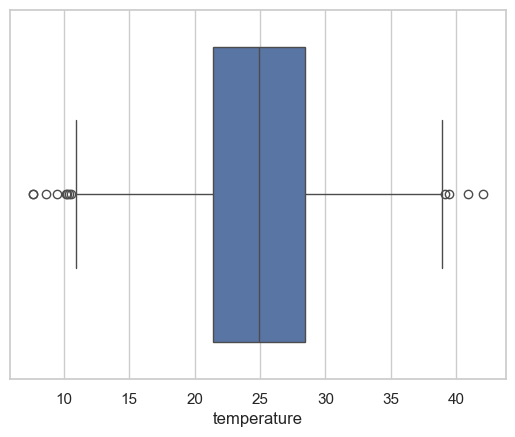

In [31]:
sns.boxplot(x=df["temperature"])

<Axes: xlabel='vibration_level'>

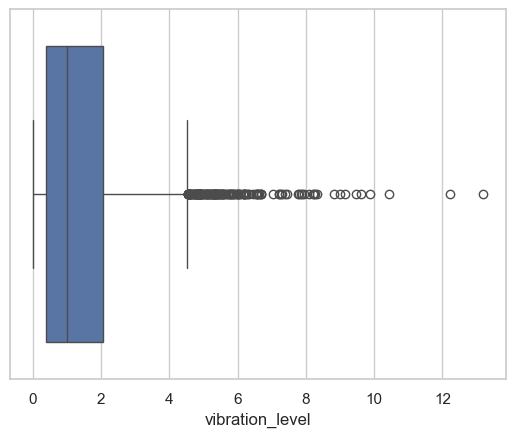

In [32]:
sns.boxplot(x=df["vibration_level"])

In [12]:
risk_percent = df['manual_risk_label'].value_counts(normalize=True) * 100
print(risk_percent)

manual_risk_label
0    67.600000
1    31.366667
2     1.033333
Name: proportion, dtype: float64


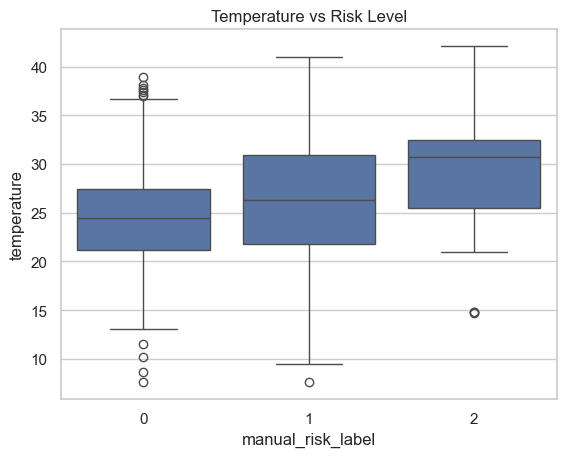

In [13]:
sns.boxplot(x="manual_risk_label", y="temperature", data=df)
plt.title("Temperature vs Risk Level")
plt.show()

# Higher temperatures tend to appear in Moderate and High Risk scenarios.

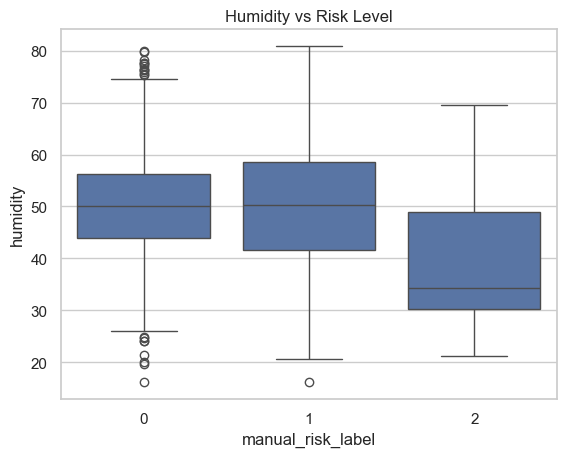

In [14]:
sns.boxplot(x="manual_risk_label", y="humidity", data=df)
plt.title("Humidity vs Risk Level")
plt.show()

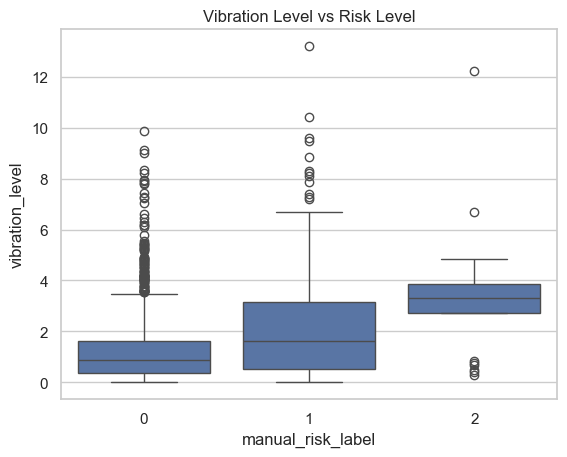

In [15]:
sns.boxplot(x="manual_risk_label", y="vibration_level", data=df)
plt.title("Vibration Level vs Risk Level")
plt.show()

# High vibration levels strongly correlate with High Risk operations.

In [19]:

df["expected_delivery_date"] = pd.to_datetime(df["expected_delivery_date"])
df["actual_delivery_date"] = pd.to_datetime(df["actual_delivery_date"])

In [21]:
df["delivery_delay_days"] = (
    df["actual_delivery_date"] - df["expected_delivery_date"]
).dt.days

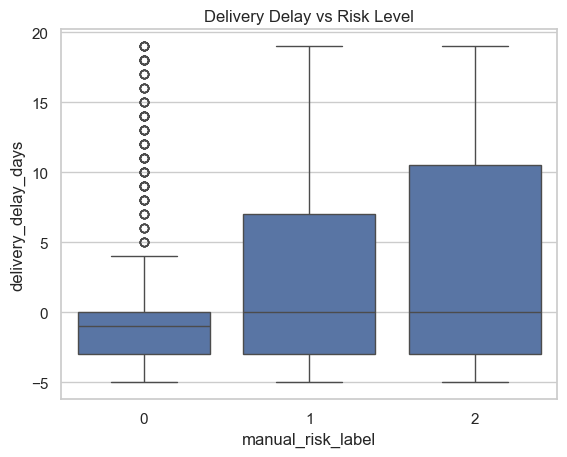

In [22]:
sns.boxplot(x="manual_risk_label", y="delivery_delay_days", data=df)
plt.title("Delivery Delay vs Risk Level")
plt.show()

# Delivery delays increase significantly for Moderate and High Risk cases.
# This suggests logistics disruptions are a major risk factor.

In [27]:
df["risk_encoded"] = df["manual_risk_label"].map({
    "No Risk":0,
    "Moderate Risk":1,
    "High Risk":2
})

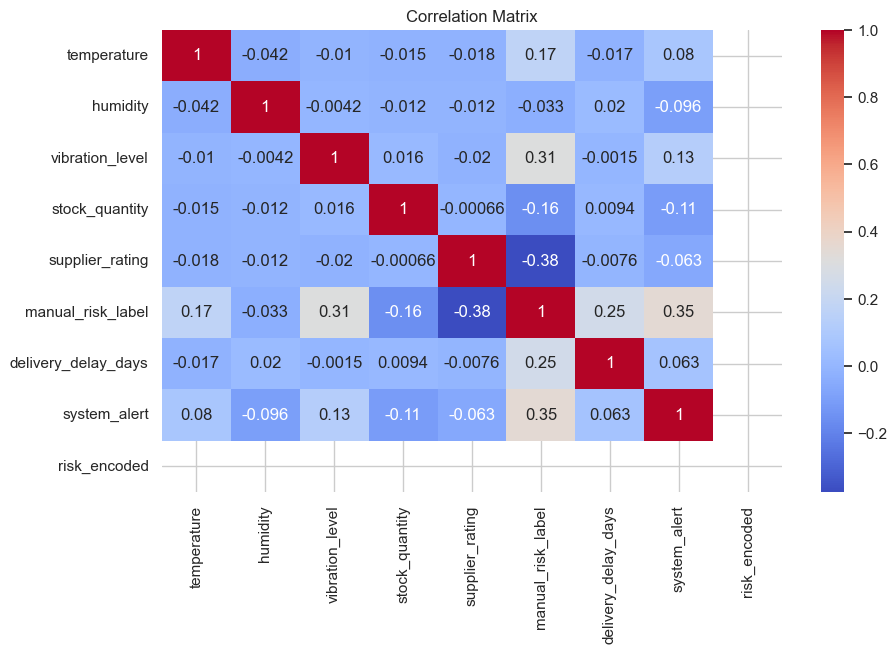

In [34]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

<Axes: xlabel='vibration_level', ylabel='delivery_delay_days'>

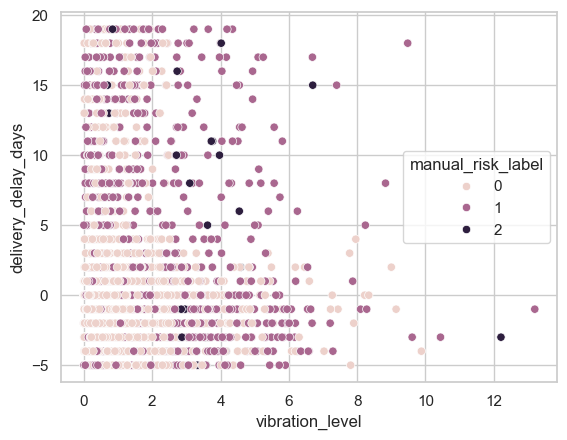

In [35]:
sns.scatterplot(
    x="vibration_level",
    y="delivery_delay_days",
    hue="manual_risk_label",
    data=df
)

# Key Insights

1. High vibration levels significantly increase supply chain risk.

2. Delivery delays strongly correlate with moderate and high risk.

3. Environmental factors such as temperature spikes contribute to system alerts.

4. Most operations fall under No Risk category indicating operational stability.